In [2]:
"""
=============================================================================
PROJECT: AI/ML Engineer Salary Prediction
AUTHOR: [Hemant]
DATE: [14/3/2026]
DESCRIPTION: This project predicts salaries of AI/ML Engineers based on
             experience, location, company size, and other factors using
             various machine learning models.
=============================================================================
"""

# =============================================================================
# PART 1: IMPORT LIBRARIES
# =============================================================================

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Machine learning models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [3]:
# =============================================================================
# PART 2: LOAD DATASET
# =============================================================================

# Upload dataset to Colab
from google.colab import files
print("📁 Please upload your dataset (CSV file):")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]

# Load the dataset
df = pd.read_csv(filename)

print(f"\n✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")
print(f"   (Rows: {df.shape[0]}, Columns: {df.shape[1]})")

# Display first few rows
print("\n👀 First 5 rows of the dataset:")
df.head()

📁 Please upload your dataset (CSV file):


Saving glassdoor_jobs.csv to glassdoor_jobs (1).csv

✅ Dataset loaded successfully!
📊 Dataset shape: (956, 15)
   (Rows: 956, Columns: 15)

👀 First 5 rows of the dataset:


,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 to 1000 employees,1973,Company - Private,Aerospace & Defense,Aerospace & Defense,$50 to $100 million (USD),-1
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+ employees,1984,Other Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 to 1000 employees,2010,Company - Private,Security Services,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 to 5000 employees,1965,Government,Energy,"Oil, Gas, Energy & Utilities",$500 million to $1 billion (USD),"Oak Ridge National Laboratory, National Renewa..."
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


In [6]:
# =============================================================================
# PART 3: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

print("\n" + "="*80)
print("EXPLORATORY DATA ANALYSIS")
print("="*80)

# 3.1 Dataset Information
print("\n📋 Dataset Information:")
print(df.info())

# 3.2 Statistical Summary
print("\n📊 Statistical Summary:")
print(df.describe())

# 3.3 Check for missing values
print("\n🔍 Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("✅ No missing values found!")

# 3.4 Check for duplicates
duplicates = df.duplicated().sum()
print(f"\n🔍 Duplicate Rows: {duplicates}")


EXPLORATORY DATA ANALYSIS

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         956 non-null    int64  
 1   Job Title          956 non-null    object 
 2   Salary Estimate    956 non-null    object 
 3   Job Description    956 non-null    object 
 4   Rating             956 non-null    float64
 5   Company Name       956 non-null    object 
 6   Location           956 non-null    object 
 7   Headquarters       956 non-null    object 
 8   Size               956 non-null    object 
 9   Founded            956 non-null    int64  
 10  Type of ownership  956 non-null    object 
 11  Industry           956 non-null    object 
 12  Sector             956 non-null    object 
 13  Revenue            956 non-null    object 
 14  Competitors        956 non-null    object 
dtypes: float64(1), int64(2)

In [9]:
# =============================================================================
# PART 4: DATA CLEANING
# =============================================================================

print("\n" + "="*80)
print("DATA CLEANING")
print("="*80)

# Create a copy of the original dataset
df_clean = df.copy()

# 4.1 Remove duplicates (if any)
if duplicates > 0:
    df_clean = df_clean.drop_duplicates()
    print(f"✅ Removed {duplicates} duplicate rows")

# 4.2 Handle missing values
# Example: Fill or drop missing values based on your dataset
# df_clean = df_clean.dropna()  # Uncomment if you want to drop rows with missing values
# df_clean['column_name'].fillna(df_clean['column_name'].median(), inplace=True)  # Fill with median

# 4.3 Process 'Salary Estimate' column to create 'salary_in_usd'
print("\n⚙️ Processing 'Salary Estimate' column...")

# Remove rows with '-1' in Salary Estimate as they are not valid salary values
df_clean = df_clean[df_clean['Salary Estimate'] != '-1']

# Remove ' (Glassdoor est.)' and other suffixes
df_clean['Salary Estimate'] = df_clean['Salary Estimate'].apply(lambda x: x.split('(')[0] if '(' in x else x)

# Remove 'K', '$', and 'Per Hour'/'Employer Provided Salary' tags
df_clean['Salary Estimate'] = df_clean['Salary Estimate'].str.replace('K','').str.replace('$','')

# Filter out 'Per Hour' and 'Employer Provided Salary' entries
df_clean = df_clean[~df_clean['Salary Estimate'].str.contains('Per Hour')]
df_clean = df_clean[~df_clean['Salary Estimate'].str.contains('Employer Provided Salary')]

# Create min_salary and max_salary columns
df_clean['min_salary'] = df_clean['Salary Estimate'].apply(lambda x: int(x.split('-')[0]))
df_clean['max_salary'] = df_clean['Salary Estimate'].apply(lambda x: int(x.split('-')[1]) if '-' in x else int(x))

# Calculate average salary and convert to USD (multiply by 1000 since original was in K)
df_clean['salary_in_usd'] = ((df_clean['min_salary'] + df_clean['max_salary']) / 2) * 1000

print("✅ 'salary_in_usd' column created successfully!")

# 4.4 Clean 'Company Name' column
df_clean['Company Name'] = df_clean['Company Name'].apply(lambda x: x.split('\n')[0])
print("✅ 'Company Name' column cleaned.")

# 4.5 Extract 'job_simple' from 'Job Title'
def get_job_simple(title):
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'machine learning' in title.lower() or 'ml engineer' in title.lower():
        return 'ml engineer'
    elif 'manager' in title.lower():
        return 'manager'
    elif 'director' in title.lower():
        return 'director'
    else:
        return 'other'

df_clean['job_simple'] = df_clean['Job Title'].apply(get_job_simple)
print("✅ 'job_simple' column created from 'Job Title'.")

# 4.6 Extract 'seniority' from 'Job Title'
def get_seniority(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    elif 'jr' in title.lower() or 'junior' in title.lower() or 'entry' in title.lower():
        return 'junior'
    else:
        return 'na'

df_clean['seniority'] = df_clean['Job Title'].apply(get_seniority)
print("✅ 'seniority' column created from 'Job Title'.")

# 4.7 Clean 'Location' and 'Headquarters' by extracting state
df_clean['job_state'] = df_clean['Location'].apply(lambda x: x.split(',')[1].strip() if ',' in x else x)
df_clean['hq_state'] = df_clean['Headquarters'].apply(lambda x: x.split(',')[1].strip() if ',' in x else x)
print("✅ 'job_state' and 'hq_state' columns created.")

# 4.8 Calculate 'age' of company
df_clean['company_age'] = df_clean.Founded.apply(lambda x: 2024 - x if x > 0 else x)
print("✅ 'company_age' column created.")

# 4.9 Extract Python, R, Spark, AWS, Excel from Job Description
# Define a function to check for keyword presence
def find_skill(description, keyword):
    return 1 if keyword.lower() in description.lower() else 0

df_clean['python_yn'] = df_clean['Job Description'].apply(lambda x: find_skill(x, 'python'))
df_clean['r_yn'] = df_clean['Job Description'].apply(lambda x: find_skill(x, 'r studio') or find_skill(x, 'r-studio'))
df_clean['spark_yn'] = df_clean['Job Description'].apply(lambda x: find_skill(x, 'spark'))
df_clean['aws_yn'] = df_clean['Job Description'].apply(lambda x: find_skill(x, 'aws'))
df_clean['excel_yn'] = df_clean['Job Description'].apply(lambda x: find_skill(x, 'excel'))
print("✅ Skill columns (python_yn, r_yn, spark_yn, aws_yn, excel_yn) created from 'Job Description'.")

# 4.10 Drop original salary estimate columns and other unnecessary columns
df_clean = df_clean.drop(['Unnamed: 0', 'Salary Estimate', 'min_salary', 'max_salary', 'Job Description'], axis=1)
print("✅ Original salary estimate and job description columns dropped.")


# 4.3 Rename columns for easier access (adjust based on your dataset)
# Example column names - ADJUST THESE based on your actual dataset columns
# Common columns in salary datasets:
# - work_year, experience_level, employment_type, job_title, salary,
#   salary_currency, salary_in_usd, employee_residence, remote_ratio,
#   company_location, company_size

print("\n📋 Column Names:")
print(df_clean.columns.tolist())

# Display cleaned dataset shape
print(f"\n✅ Cleaned Dataset Shape: {df_clean.shape}")


DATA CLEANING

⚙️ Processing 'Salary Estimate' column...
✅ 'salary_in_usd' column created successfully!
✅ 'Company Name' column cleaned.
✅ 'job_simple' column created from 'Job Title'.
✅ 'seniority' column created from 'Job Title'.
✅ 'job_state' and 'hq_state' columns created.
✅ 'company_age' column created.
✅ Skill columns (python_yn, r_yn, spark_yn, aws_yn, excel_yn) created from 'Job Description'.
✅ Original salary estimate and job description columns dropped.

📋 Column Names:
['Job Title', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'salary_in_usd', 'job_simple', 'seniority', 'job_state', 'hq_state', 'company_age', 'python_yn', 'r_yn', 'spark_yn', 'aws_yn', 'excel_yn']

✅ Cleaned Dataset Shape: (704, 23)



DATA VISUALIZATION


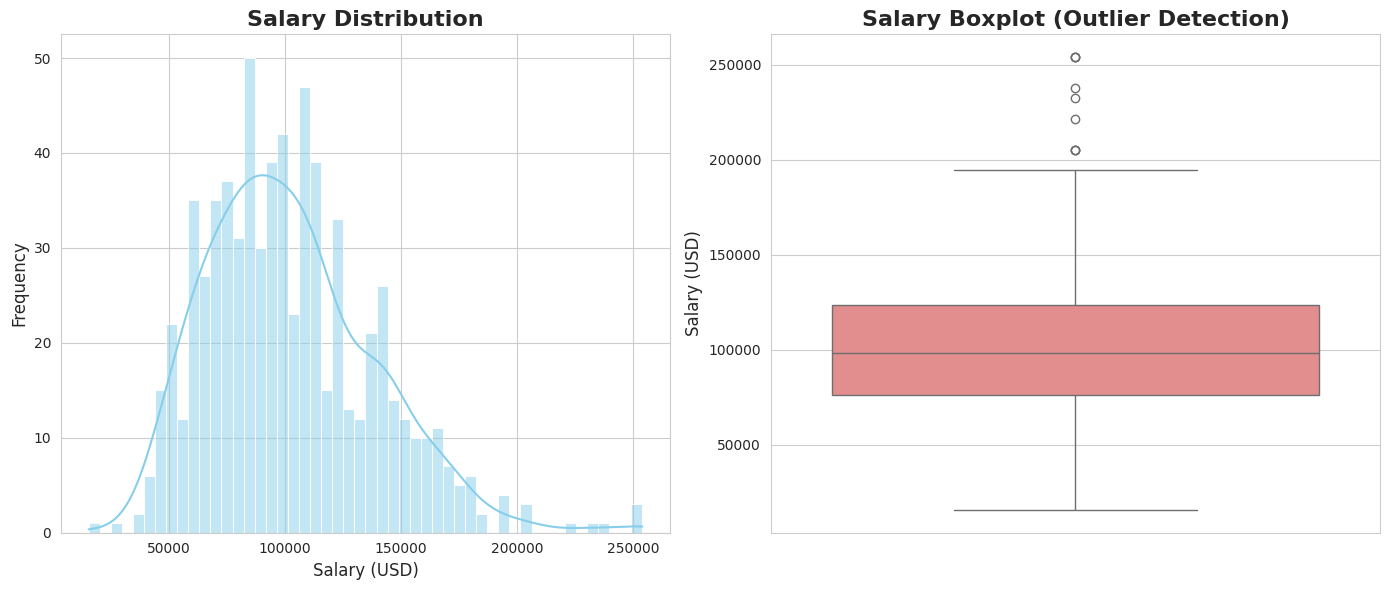

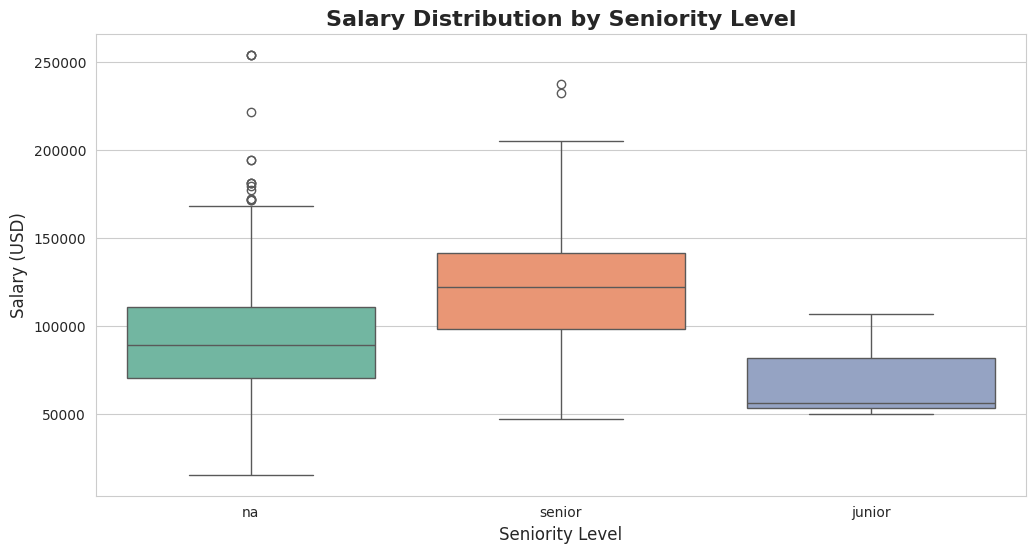

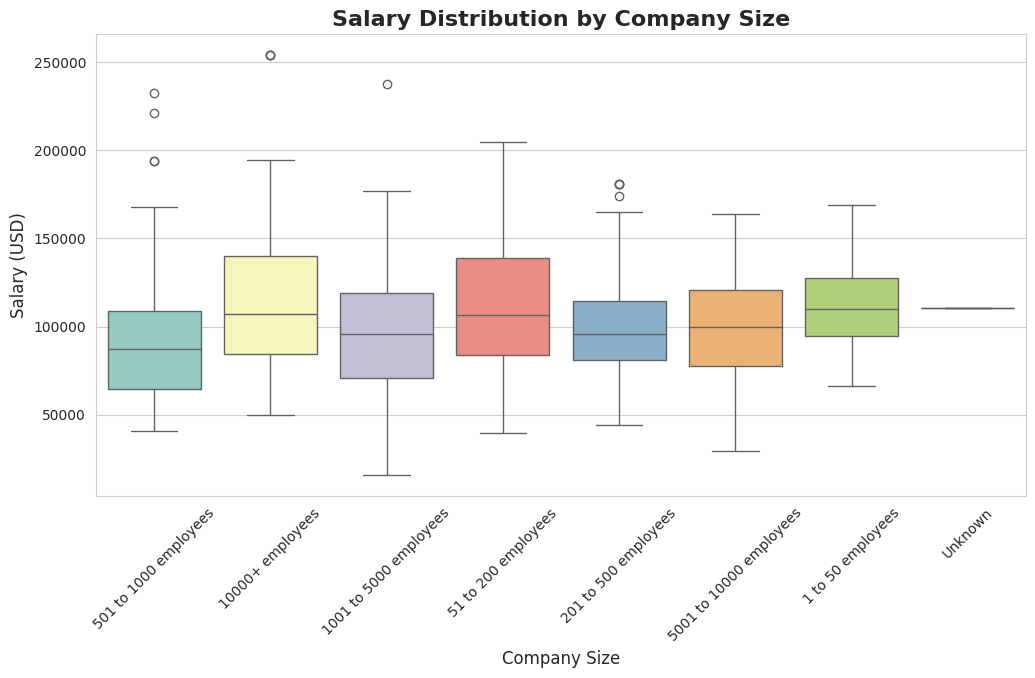

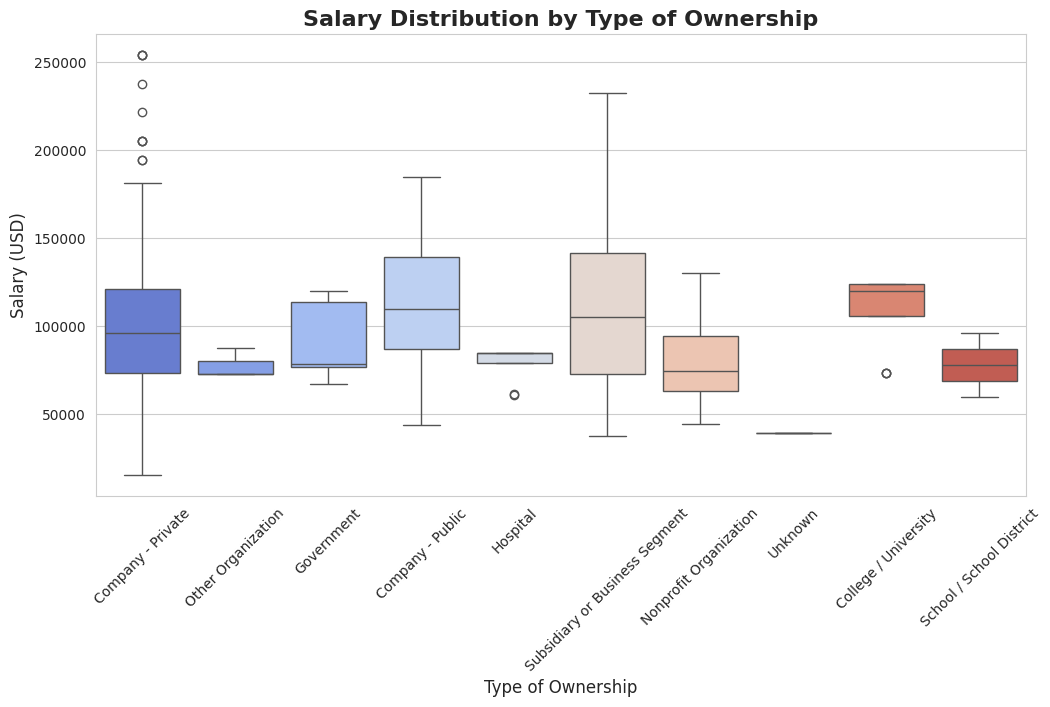

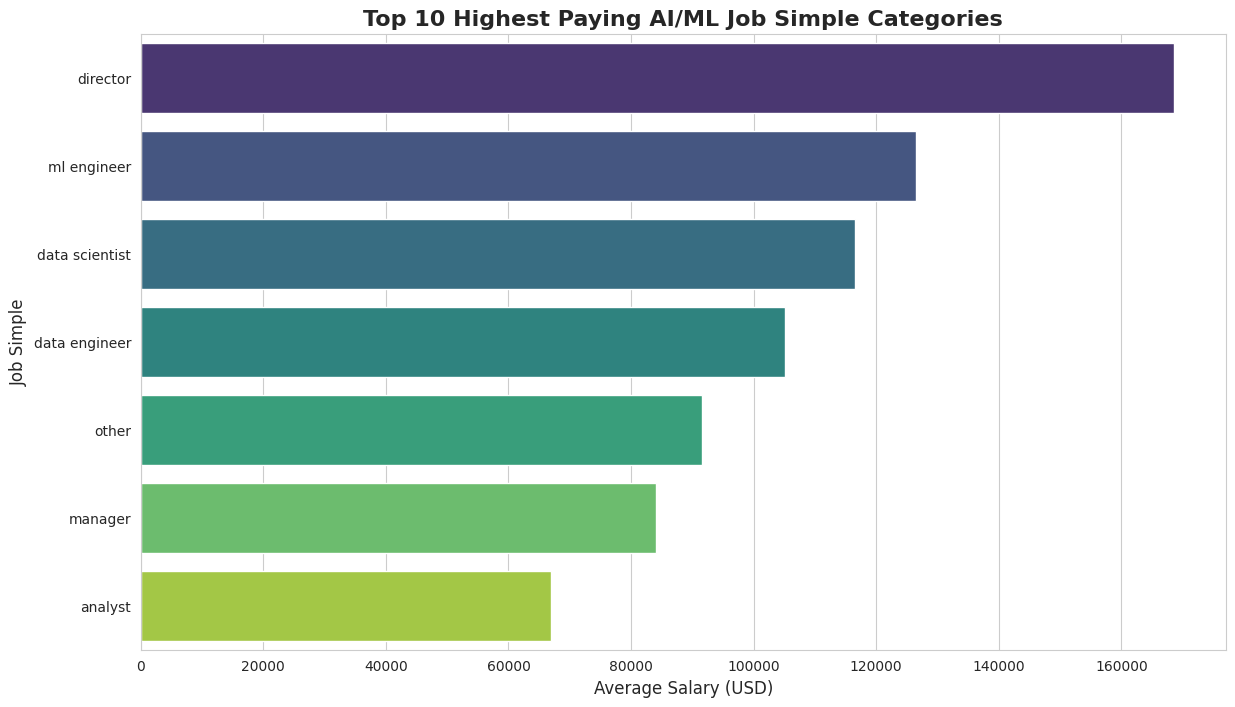

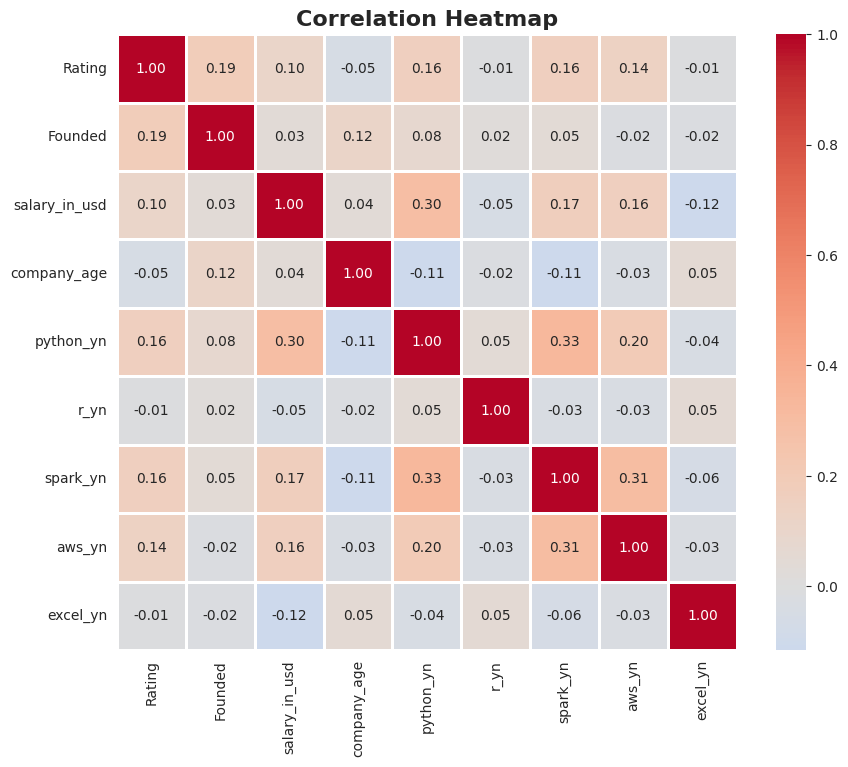

✅ Visualizations completed!


In [10]:
# =============================================================================
# PART 5: DATA VISUALIZATION
# =============================================================================

print("\n" + "="*80)
print("DATA VISUALIZATION")
print("="*80)

# 5.1 Salary Distribution
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# ADJUST 'salary_in_usd' to match your actual salary column name
sns.histplot(df_clean['salary_in_usd'], bins=50, kde=True, color='skyblue')
plt.title('Salary Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Salary (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['salary_in_usd'], color='lightcoral')
plt.title('Salary Boxplot (Outlier Detection)', fontsize=16, fontweight='bold')
plt.ylabel('Salary (USD)', fontsize=12)

plt.tight_layout()
plt.show()

# 5.2 Salary by Experience Level
plt.figure(figsize=(12, 6))
# ADJUST column names based on your dataset
sns.boxplot(data=df_clean, x='seniority', y='salary_in_usd', palette='Set2')
plt.title('Salary Distribution by Seniority Level', fontsize=16, fontweight='bold')
plt.xlabel('Seniority Level', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(rotation=0)
plt.show()

# 5.3 Salary by Company Size
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='Size', y='salary_in_usd', palette='Set3')
plt.title('Salary Distribution by Company Size', fontsize=16, fontweight='bold')
plt.xlabel('Company Size', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 5.4 Salary by Employment Type
# This dataset does not appear to have an 'employment_type' column, using 'Type of ownership' instead as an example
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_clean, x='Type of ownership', y='salary_in_usd', palette='coolwarm')
plt.title('Salary Distribution by Type of Ownership', fontsize=16, fontweight='bold')
plt.xlabel('Type of Ownership', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# 5.5 Top 10 Job Titles by Average Salary
plt.figure(figsize=(14, 8))
top_jobs = df_clean.groupby('job_simple')['salary_in_usd'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_jobs.values, y=top_jobs.index, palette='viridis')
plt.title('Top 10 Highest Paying AI/ML Job Simple Categories', fontsize=16, fontweight='bold')
plt.xlabel('Average Salary (USD)', fontsize=12)
plt.ylabel('Job Simple', fontsize=12)
plt.show()

# 5.6 Correlation Heatmap (for numerical features)
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            linewidths=1, linecolor='white', fmt='.2f')
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

print("✅ Visualizations completed!")


In [13]:
# =============================================================================
# PART 6: FEATURE ENGINEERING
# =============================================================================

print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Create a copy for feature engineering
df_model = df_clean.copy()

# 6.1 Encode Categorical Variables
# Initialize Label Encoder
le = LabelEncoder()

# List of categorical columns to encode (ADJUST based on your dataset)
# Updated based on df_clean.columns:
# ['Job Title', 'Rating', 'Company Name', 'Location', 'Headquarters', 'Size', 'Founded', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors', 'salary_in_usd', 'job_simple', 'seniority', 'job_state', 'hq_state', 'company_age', 'python_yn', 'r_yn', 'spark_yn', 'aws_yn', 'excel_yn']
categorical_columns = ['job_simple', 'seniority', 'Size', 'Type of ownership', 'Industry', 'Sector', 'Revenue', 'job_state', 'hq_state']

# Encode each categorical column
for col in categorical_columns:
    if col in df_model.columns:
        df_model[col + '_encoded'] = le.fit_transform(df_model[col])
        print(f"✅ Encoded: {col}")

# 6.2 Select features for modeling
# ADJUST these based on your dataset and analysis
# Combined numerical and newly encoded categorical features
feature_columns = [
    'Rating',
    'company_age',
    'python_yn',
    'r_yn',
    'spark_yn',
    'aws_yn',
    'excel_yn',
    'job_simple_encoded',
    'seniority_encoded',
    'Size_encoded',
    'Type of ownership_encoded',
    'Industry_encoded',
    'Sector_encoded',
    'Revenue_encoded',
    'job_state_encoded',
    'hq_state_encoded'
]

# Check if all feature columns exist
feature_columns = [col for col in feature_columns if col in df_model.columns]

X = df_model[feature_columns]
y = df_model['salary_in_usd']  # Target variable

print(f"\n📊 Features selected: {len(feature_columns)}")
print(f"   {feature_columns}")
print(f"\n🎯 Target variable: salary_in_usd")


FEATURE ENGINEERING
✅ Encoded: job_simple
✅ Encoded: seniority
✅ Encoded: Size
✅ Encoded: Type of ownership
✅ Encoded: Industry
✅ Encoded: Sector
✅ Encoded: Revenue
✅ Encoded: job_state
✅ Encoded: hq_state

📊 Features selected: 16
   ['Rating', 'company_age', 'python_yn', 'r_yn', 'spark_yn', 'aws_yn', 'excel_yn', 'job_simple_encoded', 'seniority_encoded', 'Size_encoded', 'Type of ownership_encoded', 'Industry_encoded', 'Sector_encoded', 'Revenue_encoded', 'job_state_encoded', 'hq_state_encoded']

🎯 Target variable: salary_in_usd


In [14]:
# =============================================================================
# PART 7: TRAIN-TEST SPLIT
# =============================================================================

print("\n" + "="*80)
print("TRAIN-TEST SPLIT")
print("="*80)

# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data split completed!")
print(f"   Training set: {X_train.shape[0]} samples")
print(f"   Testing set: {X_test.shape[0]} samples")

# Feature Scaling (important for some models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Feature scaling completed!")


TRAIN-TEST SPLIT
✅ Data split completed!
   Training set: 563 samples
   Testing set: 141 samples
✅ Feature scaling completed!


In [16]:
# =============================================================================
# PART 8: MODEL TRAINING
# =============================================================================

print("\n" + "="*80)
print("MODEL TRAINING")
print("="*80)

# Dictionary to store models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Dictionary to store results
results = {}

# Train each model and evaluate
for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {
        'Model': model,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2,
        'Predictions': y_pred
    }

    print(f"✅ {name} trained successfully!")
    print(f"   MAE: ${mae:,.2f}")
    print(f"   RMSE: ${rmse:,.2f}")
    print(f"   R² Score: {r2:.4f}")



MODEL TRAINING

🔄 Training Linear Regression...
✅ Linear Regression trained successfully!
   MAE: $24,769.75
   RMSE: $30,989.80
   R² Score: 0.3065

🔄 Training Ridge Regression...
✅ Ridge Regression trained successfully!
   MAE: $24,573.69
   RMSE: $30,731.94
   R² Score: 0.3180

🔄 Training Lasso Regression...
✅ Lasso Regression trained successfully!
   MAE: $24,766.20
   RMSE: $30,983.15
   R² Score: 0.3068

🔄 Training Decision Tree...
✅ Decision Tree trained successfully!
   MAE: $10,990.78
   RMSE: $23,913.96
   R² Score: 0.5870

🔄 Training Random Forest...
✅ Random Forest trained successfully!
   MAE: $12,987.76
   RMSE: $20,226.51
   R² Score: 0.7046

🔄 Training Gradient Boosting...
✅ Gradient Boosting trained successfully!
   MAE: $16,600.64
   RMSE: $22,492.84
   R² Score: 0.6346



MODEL COMPARISON

📊 Model Performance Comparison:
            Model          MAE         RMSE  R2 Score
    Random Forest 12987.760147 20226.514610  0.704556
Gradient Boosting 16600.642090 22492.839959  0.634640
    Decision Tree 10990.780142 23913.962211  0.587013
 Ridge Regression 24573.689483 30731.939581  0.317955
 Lasso Regression 24766.201653 30983.150901  0.306759
Linear Regression 24769.746355 30989.797015  0.306462


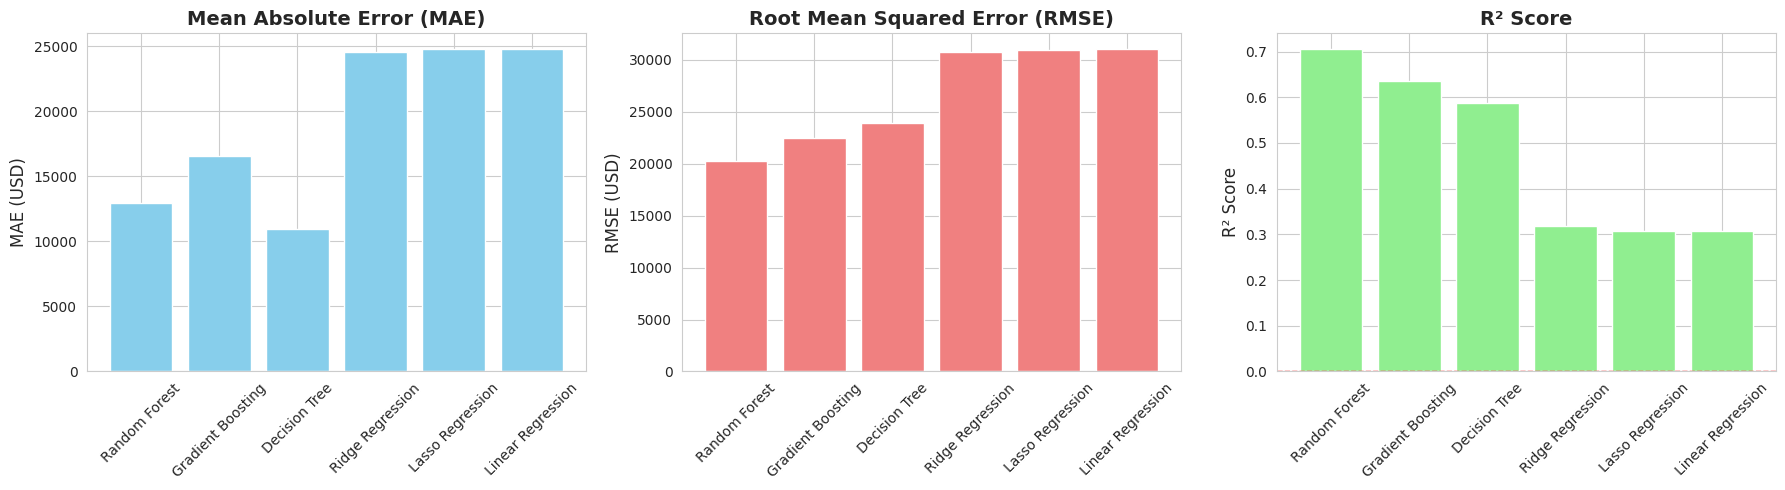

In [17]:
# =============================================================================
# PART 9: MODEL COMPARISON
# =============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MAE': [results[m]['MAE'] for m in results.keys()],
    'RMSE': [results[m]['RMSE'] for m in results.keys()],
    'R2 Score': [results[m]['R2 Score'] for m in results.keys()]
})

# Sort by R2 Score (higher is better)
comparison_df = comparison_df.sort_values('R2 Score', ascending=False)

print("\n📊 Model Performance Comparison:")
print(comparison_df.to_string(index=False))

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE Comparison
axes[0].bar(comparison_df['Model'], comparison_df['MAE'], color='skyblue')
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('MAE (USD)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# RMSE Comparison
axes[1].bar(comparison_df['Model'], comparison_df['RMSE'], color='lightcoral')
axes[1].set_title('Root Mean Squared Error (RMSE)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE (USD)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# R2 Score Comparison
axes[2].bar(comparison_df['Model'], comparison_df['R2 Score'], color='lightgreen')
axes[2].set_title('R² Score', fontsize=14, fontweight='bold')
axes[2].set_ylabel('R² Score', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()



BEST MODEL ANALYSIS

🏆 Best Model: Random Forest
   R² Score: 0.7046
   MAE: $12,987.76
   RMSE: $20,226.51


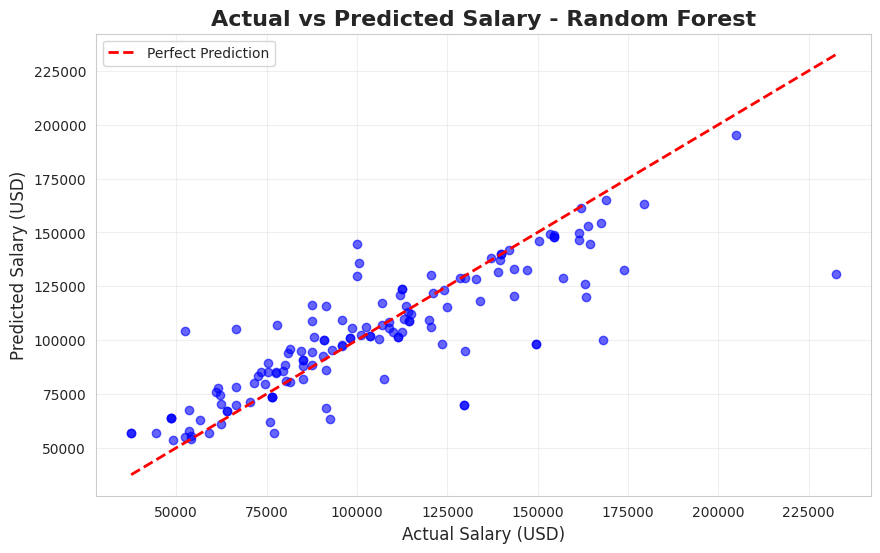

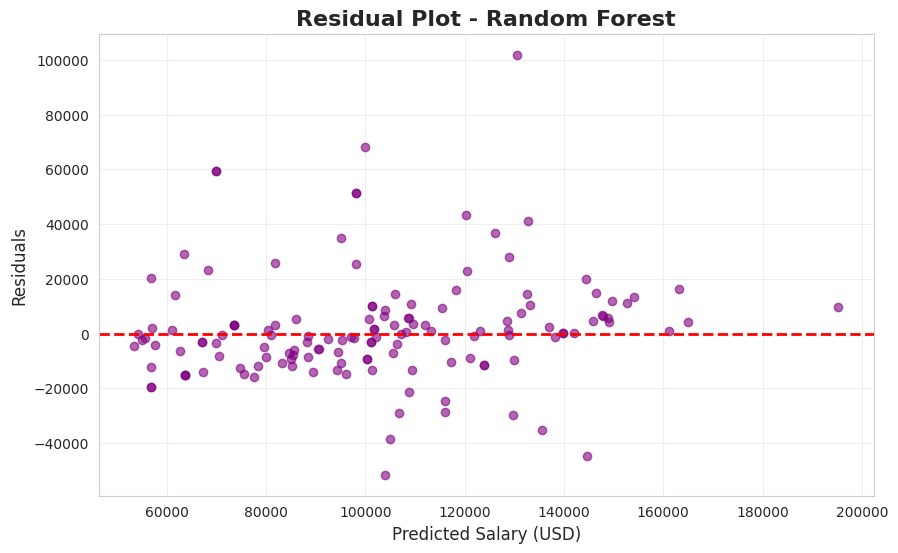

In [19]:
# =============================================================================
# PART 10: BEST MODEL ANALYSIS
# =============================================================================

print("\n" + "="*80)
print("BEST MODEL ANALYSIS")
print("="*80)

# Get the best model (highest R2 score)
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['Model']
best_predictions = results[best_model_name]['Predictions']

print(f"\n🏆 Best Model: {best_model_name}")
print(f"   R² Score: {results[best_model_name]['R2 Score']:.4f}")
print(f"   MAE: ${results[best_model_name]['MAE']:,.2f}")
print(f"   RMSE: ${results[best_model_name]['RMSE']:,.2f}")

# Actual vs Predicted Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, best_predictions, alpha=0.6, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Salary (USD)', fontsize=12)
plt.ylabel('Predicted Salary (USD)', fontsize=12)
plt.title(f'Actual vs Predicted Salary - {best_model_name}', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Residual Plot
residuals = y_test - best_predictions
plt.figure(figsize=(10, 6))
plt.scatter(best_predictions, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Salary (USD)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title(f'Residual Plot - {best_model_name}', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()



FEATURE IMPORTANCE

📊 Feature Importance:
                  Feature  Importance
       job_simple_encoded    0.265791
        job_state_encoded    0.114971
        seniority_encoded    0.112072
              company_age    0.085261
                   Rating    0.076193
         hq_state_encoded    0.057882
         Industry_encoded    0.057426
             Size_encoded    0.047628
          Revenue_encoded    0.039155
           Sector_encoded    0.038696
                python_yn    0.038190
Type of ownership_encoded    0.028858
                 excel_yn    0.019513
                   aws_yn    0.010175
                 spark_yn    0.008183
                     r_yn    0.000008


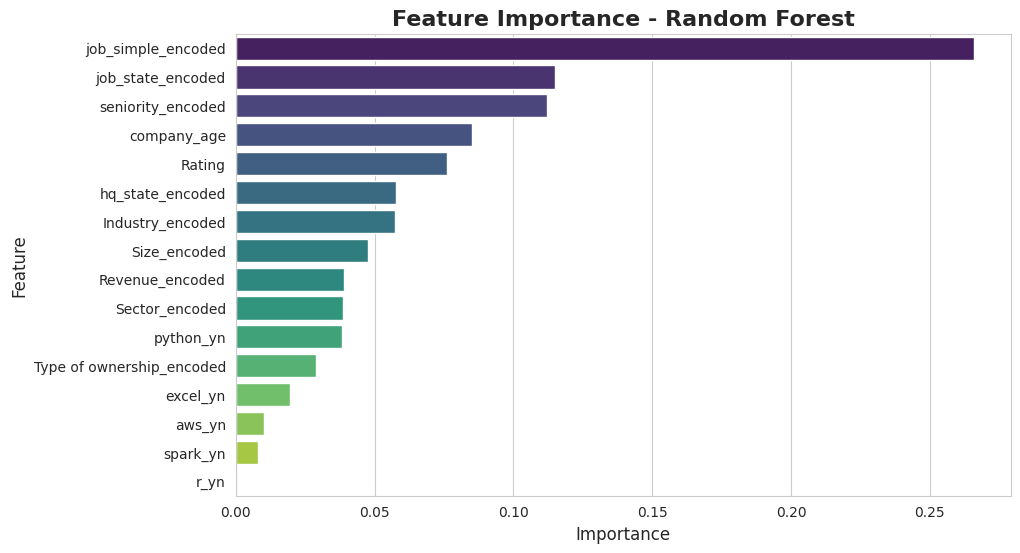

In [20]:
# =============================================================================
# PART 11: FEATURE IMPORTANCE (for tree-based models)
# =============================================================================

if best_model_name in ['Decision Tree', 'Random Forest', 'Gradient Boosting']:
    print("\n" + "="*80)
    print("FEATURE IMPORTANCE")
    print("="*80)

    # Get feature importances
    importances = best_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print("\n📊 Feature Importance:")
    print(feature_importance_df.to_string(index=False))

    # Visualize feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=16, fontweight='bold')
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.show()



In [21]:
# =============================================================================
# PART 12: SAVE THE MODEL
# =============================================================================

print("\n" + "="*80)
print("SAVE MODEL")
print("="*80)

import pickle

# Save the best model
model_filename = 'best_salary_prediction_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f"✅ Best model saved as '{model_filename}'")

# Save the scaler
scaler_filename = 'feature_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

print(f"✅ Scaler saved as '{scaler_filename}'")

# Download the model files
from google.colab import files
files.download(model_filename)
files.download(scaler_filename)

print("\n🎉 Project completed successfully!")



SAVE MODEL
✅ Best model saved as 'best_salary_prediction_model.pkl'
✅ Scaler saved as 'feature_scaler.pkl'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Project completed successfully!


In [24]:
# =============================================================================
# PART 13: MAKE PREDICTIONS ON NEW DATA (Example)
# =============================================================================

print("\n" + "="*80)
print("EXAMPLE: PREDICT SALARY FOR NEW DATA")
print("="*80)

# Example: Create a sample data point
# ADJUST values based on your features
sample_data = pd.DataFrame([[0]*len(feature_columns)], columns=feature_columns) # Create an empty dataframe with the correct columns

# Assign example values (adjust these based on your actual feature ranges and meanings)
sample_data['Rating'] = 4.0
sample_data['company_age'] = 10
sample_data['python_yn'] = 1
sample_data['r_yn'] = 0
sample_data['spark_yn'] = 1
sample_data['aws_yn'] = 1
sample_data['excel_yn'] = 0
sample_data['job_simple_encoded'] = 2 # e.g., data scientist
sample_data['seniority_encoded'] = 2 # e.g., senior
sample_data['Size_encoded'] = 3 # e.g., 501 to 1000 employees
sample_data['Type of ownership_encoded'] = 0 # e.g., Company - Private
sample_data['Industry_encoded'] = 10 # example value
sample_data['Sector_encoded'] = 5 # example value
sample_data['Revenue_encoded'] = 5 # example value
sample_data['job_state_encoded'] = 15 # example value
sample_data['hq_state_encoded'] = 15 # example value

# Scale the sample data using the fitted scaler
sample_data_scaled = scaler.transform(sample_data)

# Make prediction
predicted_salary = best_model.predict(sample_data_scaled)

print(f"\n💰 Predicted Salary: ${predicted_salary[0]:,.2f}")


EXAMPLE: PREDICT SALARY FOR NEW DATA

💰 Predicted Salary: $131,226.27


In [25]:
# =============================================================================
# END OF PROJECT
# =============================================================================

print("\n" + "="*80)
print("Thank you for using this AI/ML Salary Prediction Model!")
print("Don't forget to ⭐ star this project on GitHub!")
print("="*80)


Thank you for using this AI/ML Salary Prediction Model!
Don't forget to ⭐ star this project on GitHub!
